In [1]:
# only for development
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from src.experiments.ica import ICA

import numpy as np

In [10]:
X, A = ICA.generate_artificial_data(N=1000, D=6)
ICA_exp = ICA()

W_sgld, samples_sgld, iters_sgld = ICA_exp.run_sgld(X, steps=500000, batch_size=100)

KeyboardInterrupt: 

In [5]:
samples_sgld.shape

(17964, 6, 6)

In [ ]:
# corrected langevin MCMC
W_corr, samples_corr = ICA_exp.run_corrected_langevin(X, W_init=W_sgld, steps=500000)

Step 0/50000 | Acceptance Rate: 0.0000
Step 10000/50000 | Acceptance Rate: 0.7886
Step 20000/50000 | Acceptance Rate: 0.7830
Step 30000/50000 | Acceptance Rate: 0.7833
Step 40000/50000 | Acceptance Rate: 0.7836
Final Acceptance Rate: 0.7851


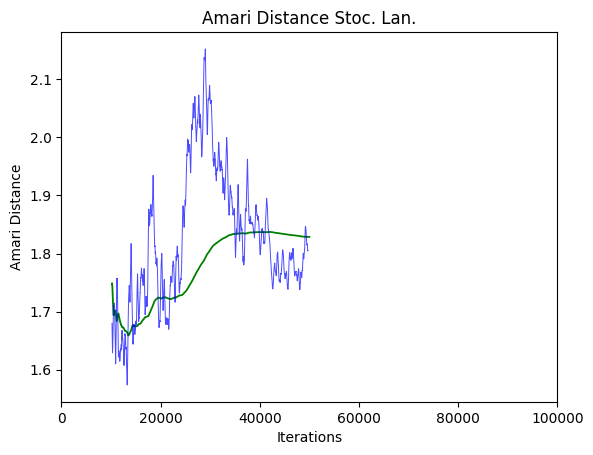

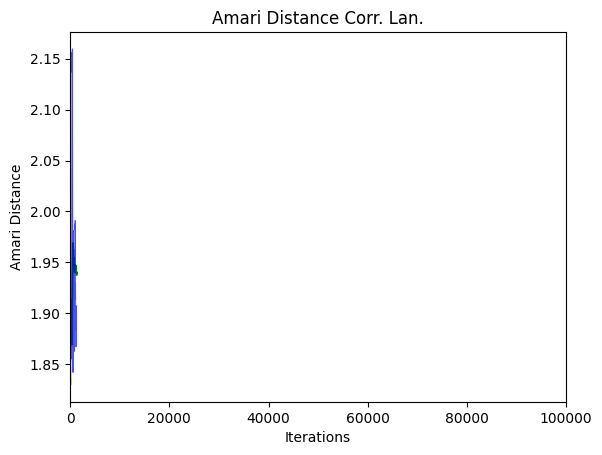

In [9]:
# amari distances
# SGLD
ICA_exp.plot_amari_distances(samples_sgld, A, iters_sgld, experiment="Stoc. Lan.")

# Corrected Langevin
iters_corr = np.arange(len(samples_corr))
ICA_exp.plot_amari_distances(samples_corr, A, iters_corr, experiment="Corr. Lan.")

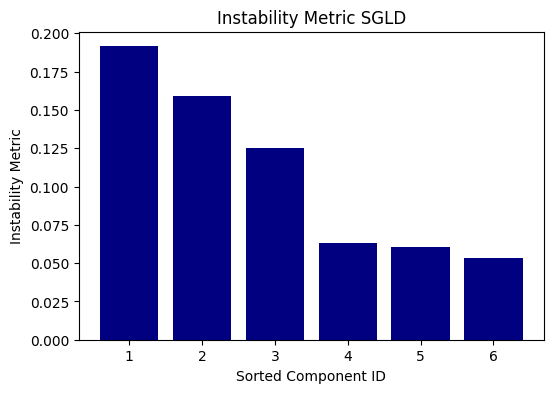

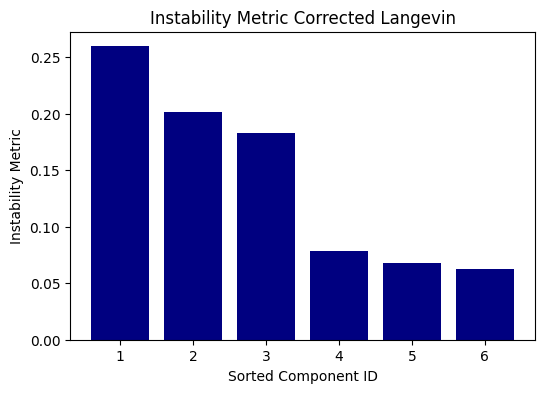

In [ ]:
# instability
# SGLD
ICA.plot_instability(samples_sgld, X, experiment="Instability Metric SGLD")

# Corrected Langevin
ICA.plot_instability(samples_corr, X, experiment="Instability Metric Corrected Langevin")

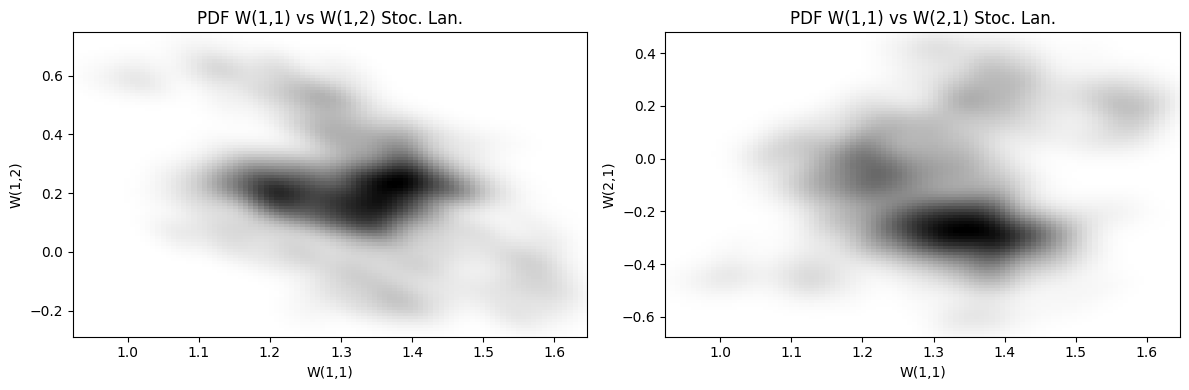

In [ ]:
# 2d pdfs
ICA.plot_2d_pdfs(samples_sgld, "Stoc. Lan.")

ICA.plot_2d_pdfs(samples_corr, "Corr. Lan.")
